In [1]:
%%capture
%run "./5.EDA_0_Cycle.ipynb"

In [2]:
required_objects = [
    "normal",
    "outlier",
    "MIN_SEGMENT_ROWS",
    "CYCLE_ANCHOR",
    "CYCLE_MIN_PEAK_DISTANCE_SAMPLES",
    "SAMPLE_RATE_HZ",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        f"5.EDA_0_Cycle.ipynb에서 필요한 객체를 찾을 수 없음: {missing_objects}"
    )

print("Reference notebook loaded successfully.")
print()
print(f"Cycle anchor                : {CYCLE_ANCHOR}")
print(f"Minimum segment rows        : {MIN_SEGMENT_ROWS}")
print(f"Minimum peak distance       : {CYCLE_MIN_PEAK_DISTANCE_SAMPLES} samples")
print(f"Sampling rate               : {SAMPLE_RATE_HZ} Hz")
print()
print(f"Normal segments             : {normal['segment_id'].nunique()}")
print(f"Outlier segments            : {outlier['segment_id'].nunique()}")

Reference notebook loaded successfully.

Cycle anchor                : AI2_Current
Minimum segment rows        : 30
Minimum peak distance       : 12 samples
Sampling rate               : 10.0 Hz

Normal segments             : 602
Outlier segments            : 21


In [3]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd


def detector_diagnostics(df, dataset_name):
    rows = []

    for segment_id, group in df.groupby("segment_id", sort=False):

        n_samples = len(group)

        # 기존 detector의 최소 segment 길이 조건
        eligible = n_samples >= MIN_SEGMENT_ROWS

        values = group[CYCLE_ANCHOR].to_numpy(dtype=float)

        smooth = (
            pd.Series(values)
            .rolling(3, center=True, min_periods=1)
            .median()
            .to_numpy()
        )

        # 기존 detector와 동일한 adaptive prominence
        if len(smooth) > 1:
            prominence = max(
                float(pd.Series(smooth).std()) * 0.5,
                np.finfo(float).eps
            )
        else:
            prominence = np.nan

        # 길이가 짧으면 기존 detector에서는 아예 검사하지 않음
        if eligible and np.isfinite(values).all():
            peaks, _ = find_peaks(
                smooth,
                distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES,
                prominence=prominence,
            )
        else:
            peaks = np.array([], dtype=int)

        peak_count = len(peaks)
        cycle_count = max(peak_count - 1, 0)

        if not eligible:
            status = "short segment"
        elif peak_count == 0:
            status = "peak 0"
        elif peak_count == 1:
            status = "peak 1"
        else:
            status = "peak 2+"

        rows.append({
            "dataset": dataset_name,
            "segment_id": int(segment_id),
            "n_samples": n_samples,
            "eligible": eligible,
            "prominence": prominence,
            "peak_count": peak_count,
            "candidate_cycle_count": cycle_count,
            "status": status,
        })

    return pd.DataFrame(rows)


normal_diag = detector_diagnostics(normal, "Normal")
outlier_diag = detector_diagnostics(outlier, "Outlier")

In [4]:
def eligibility_summary(diag):
    total = len(diag)
    eligible = int(diag["eligible"].sum())
    short = int((~diag["eligible"]).sum())

    return pd.Series({
        "total_segments": total,
        "eligible_segments": eligible,
        "short_segments": short,
        "eligible_fraction": eligible / total if total > 0 else np.nan,
    })


q1_summary = pd.DataFrame([
    eligibility_summary(normal_diag).rename("Normal"),
    eligibility_summary(outlier_diag).rename("Outlier"),
])

display(q1_summary)

print(
    f"Outlier 전체 segment : {len(outlier_diag)}"
)

print(
    f"30 samples 이상      : {outlier_diag['eligible'].sum()}"
)

print(
    f"30 samples 미만      : {(~outlier_diag['eligible']).sum()}"
)

,total_segments,eligible_segments,short_segments,eligible_fraction
Normal,602.0,360.0,242.0,0.598007
Outlier,21.0,10.0,11.0,0.476190


Outlier 전체 segment : 21
30 samples 이상      : 10
30 samples 미만      : 11


In [5]:
outlier_eligible = outlier_diag.loc[
    outlier_diag["eligible"]
].copy()

q2_summary = (
    outlier_eligible["status"]
    .value_counts()
    .reindex(
        ["peak 0", "peak 1", "peak 2+"],
        fill_value=0
    )
    .rename("segment_count")
    .to_frame()
)

display(q2_summary)

display(
    outlier_eligible[
        [
            "segment_id",
            "n_samples",
            "prominence",
            "peak_count",
            "candidate_cycle_count",
            "status",
        ]
    ]
    .sort_values("segment_id")
)

print(
    "Total Outlier candidate cycles:",
    int(outlier_eligible["candidate_cycle_count"].sum())
)

,segment_count
status,
peak 0,0
peak 1,4
peak 2+,6


,segment_id,n_samples,prominence,peak_count,candidate_cycle_count,status
1,1,50,36.590682,3,2,peak 2+
2,2,47,46.694791,1,0,peak 1
3,3,31,14.915609,1,0,peak 1
6,6,50,55.562649,2,1,peak 2+
7,7,40,62.209947,1,0,peak 1
11,11,50,23.973002,3,2,peak 2+
12,12,42,30.507035,2,1,peak 2+
15,15,50,59.148550,1,0,peak 1
16,16,50,46.766511,2,1,peak 2+
17,17,36,56.893168,2,1,peak 2+


Total Outlier candidate cycles: 8


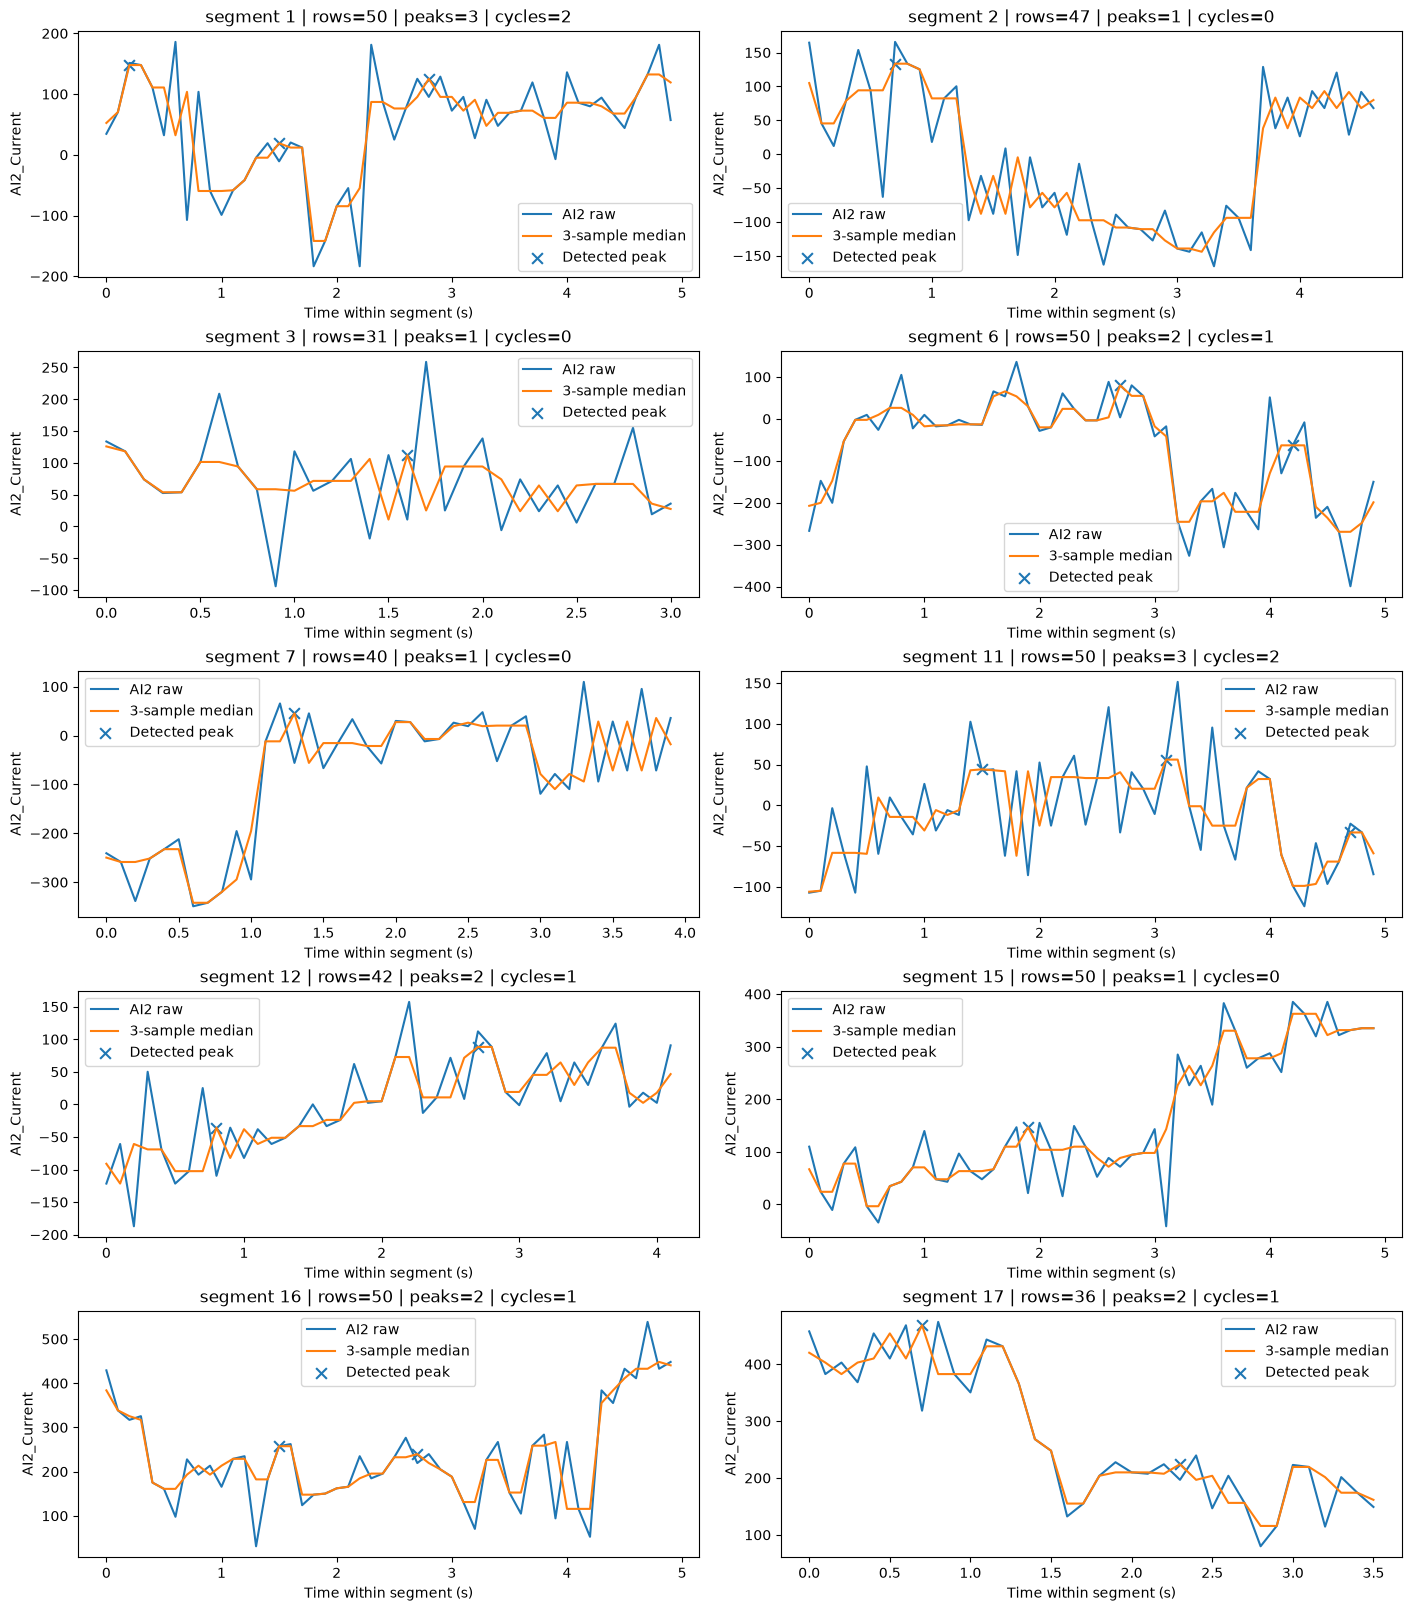

In [6]:
import matplotlib.pyplot as plt
import math

eligible_ids = (
    outlier_eligible["segment_id"]
    .astype(int)
    .tolist()
)

n = len(eligible_ids)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 3.2 * nrows),
    constrained_layout=True
)

axes = np.atleast_1d(axes).ravel()

for ax, segment_id in zip(axes, eligible_ids):

    group = outlier.loc[
        outlier["segment_id"] == segment_id
    ]

    raw = group[CYCLE_ANCHOR].to_numpy(dtype=float)

    smooth = (
        pd.Series(raw)
        .rolling(3, center=True, min_periods=1)
        .median()
        .to_numpy()
    )

    row = outlier_eligible.loc[
        outlier_eligible["segment_id"] == segment_id
    ].iloc[0]

    prominence = float(row["prominence"])

    peaks, _ = find_peaks(
        smooth,
        distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES,
        prominence=prominence,
    )

    time = np.arange(len(group)) / SAMPLE_RATE_HZ

    ax.plot(time, raw, label="AI2 raw")
    ax.plot(time, smooth, label="3-sample median")

    if len(peaks):
        ax.scatter(
            time[peaks],
            smooth[peaks],
            marker="x",
            s=60,
            label="Detected peak",
        )

    ax.set_title(
        f"segment {segment_id} | "
        f"rows={len(group)} | "
        f"peaks={len(peaks)} | "
        f"cycles={max(len(peaks)-1, 0)}"
    )

    ax.set_xlabel("Time within segment (s)")
    ax.set_ylabel(CYCLE_ANCHOR)
    ax.legend()

for ax in axes[n:]:
    ax.set_visible(False)

plt.show()

In [7]:
normal_eligible = normal_diag.loc[
    normal_diag["eligible"]
].copy()

FIXED_NORMAL_PROMINENCE = float(
    normal_eligible["prominence"].median()
)

print(
    f"Normal-derived fixed prominence = "
    f"{FIXED_NORMAL_PROMINENCE:.6g}"
)

Normal-derived fixed prominence = 49.6171


In [8]:
def detect_with_fixed_prominence(
    df,
    dataset_name,
    fixed_prominence,
):
    rows = []

    for segment_id, group in df.groupby(
        "segment_id",
        sort=False
    ):

        if len(group) < MIN_SEGMENT_ROWS:
            continue

        values = group[CYCLE_ANCHOR].to_numpy(dtype=float)

        if not np.isfinite(values).all():
            continue

        smooth = (
            pd.Series(values)
            .rolling(3, center=True, min_periods=1)
            .median()
            .to_numpy()
        )

        peaks, _ = find_peaks(
            smooth,
            distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES,
            prominence=fixed_prominence,
        )

        rows.append({
            "dataset": dataset_name,
            "segment_id": int(segment_id),
            "peak_count_fixed": len(peaks),
            "candidate_cycle_count_fixed":
                max(len(peaks) - 1, 0),
        })

    return pd.DataFrame(rows)


normal_fixed = detect_with_fixed_prominence(
    normal,
    "Normal",
    FIXED_NORMAL_PROMINENCE,
)

outlier_fixed = detect_with_fixed_prominence(
    outlier,
    "Outlier",
    FIXED_NORMAL_PROMINENCE,
)

In [9]:
adaptive_vs_fixed = (
    outlier_eligible[
        [
            "segment_id",
            "n_samples",
            "peak_count",
            "candidate_cycle_count",
        ]
    ]
    .merge(
        outlier_fixed,
        on="segment_id",
        how="left",
    )
    .rename(columns={
        "peak_count": "peak_count_adaptive",
        "candidate_cycle_count":
            "candidate_cycle_count_adaptive",
    })
)

adaptive_vs_fixed["peak_difference"] = (
    adaptive_vs_fixed["peak_count_fixed"]
    - adaptive_vs_fixed["peak_count_adaptive"]
)

display(adaptive_vs_fixed)

print(
    "Adaptive total peaks:",
    adaptive_vs_fixed[
        "peak_count_adaptive"
    ].sum()
)

print(
    "Fixed total peaks:",
    adaptive_vs_fixed[
        "peak_count_fixed"
    ].sum()
)

print(
    "Adaptive candidate cycles:",
    adaptive_vs_fixed[
        "candidate_cycle_count_adaptive"
    ].sum()
)

print(
    "Fixed candidate cycles:",
    adaptive_vs_fixed[
        "candidate_cycle_count_fixed"
    ].sum()
)

,segment_id,n_samples,peak_count_adaptive,candidate_cycle_count_adaptive,dataset,peak_count_fixed,candidate_cycle_count_fixed,peak_difference
0,1,50,3,2,Outlier,3,2,0
1,2,47,1,0,Outlier,1,0,0
2,3,31,1,0,Outlier,1,0,0
3,6,50,2,1,Outlier,2,1,0
4,7,40,1,0,Outlier,2,1,1
5,11,50,3,2,Outlier,2,1,-1
6,12,42,2,1,Outlier,1,0,-1
7,15,50,1,0,Outlier,2,1,1
8,16,50,2,1,Outlier,2,1,0
9,17,36,2,1,Outlier,2,1,0


Adaptive total peaks: 18
Fixed total peaks: 18
Adaptive candidate cycles: 8
Fixed candidate cycles: 8


In [10]:
def detector_sensitivity(
    df,
    dataset_name,
    base_prominence,
):

    rows = []

    prominence_factors = [
        0.8,
        1.0,
        1.2,
    ]

    peak_distances = [
        10,
        12,
        14,
    ]

    for prominence_factor in prominence_factors:
        for distance in peak_distances:

            total_peaks = 0
            total_cycles = 0
            eligible_segments = 0
            segments_with_cycle = 0

            threshold = (
                base_prominence
                * prominence_factor
            )

            for segment_id, group in df.groupby(
                "segment_id",
                sort=False
            ):

                if len(group) < MIN_SEGMENT_ROWS:
                    continue

                values = group[
                    CYCLE_ANCHOR
                ].to_numpy(dtype=float)

                if not np.isfinite(values).all():
                    continue

                eligible_segments += 1

                smooth = (
                    pd.Series(values)
                    .rolling(
                        3,
                        center=True,
                        min_periods=1
                    )
                    .median()
                    .to_numpy()
                )

                peaks, _ = find_peaks(
                    smooth,
                    distance=distance,
                    prominence=threshold,
                )

                cycles = max(
                    len(peaks) - 1,
                    0
                )

                total_peaks += len(peaks)
                total_cycles += cycles

                if cycles > 0:
                    segments_with_cycle += 1

            rows.append({
                "dataset": dataset_name,
                "prominence_factor":
                    prominence_factor,
                "peak_distance":
                    distance,
                "eligible_segments":
                    eligible_segments,
                "segments_with_cycle":
                    segments_with_cycle,
                "total_peaks":
                    total_peaks,
                "total_candidate_cycles":
                    total_cycles,
            })

    return pd.DataFrame(rows)


normal_sensitivity = detector_sensitivity(
    normal,
    "Normal",
    FIXED_NORMAL_PROMINENCE,
)

outlier_sensitivity = detector_sensitivity(
    outlier,
    "Outlier",
    FIXED_NORMAL_PROMINENCE,
)

sensitivity = pd.concat(
    [
        normal_sensitivity,
        outlier_sensitivity,
    ],
    ignore_index=True,
)

display(sensitivity)

,dataset,prominence_factor,peak_distance,eligible_segments,segments_with_cycle,total_peaks,total_candidate_cycles
0,Normal,0.8,10,360,340,852,492
1,Normal,0.8,12,360,340,852,492
2,Normal,0.8,14,360,340,852,492
3,Normal,1.0,10,360,338,844,484
4,Normal,1.0,12,360,338,844,484
5,Normal,1.0,14,360,338,844,484
6,Normal,1.2,10,360,338,841,481
7,Normal,1.2,12,360,338,841,481
8,Normal,1.2,14,360,338,841,481
9,Outlier,0.8,10,10,10,24,14
